<a href="https://colab.research.google.com/github/Jhwan02/AI_LAB/blob/main/week12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
# Cell 1 — 라이브러리 설정
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Seed 고정
torch.manual_seed(42)
np.random.seed(42)

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


Using device: cuda


In [39]:
# Cell 2 — 데이터 로드
path = "/content/drive/MyDrive/Colab Notebooks/인공지능수업/Student_Performance.csv"
data = pd.read_csv(path)

data.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [40]:
# Cell 3 — Feature, Target 분리
X = data.drop(columns=["Performance Index"])
y = data["Performance Index"]

print("Number of samples:", len(X))
print("Number of features:", X.shape[1])
print("Feature columns:", X.columns.tolist())

Number of samples: 10000
Number of features: 5
Feature columns: ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 'Sleep Hours', 'Sample Question Papers Practiced']


In [41]:
# Cell 4 — Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))

# One-hot encoding (categorical: Extracurricular Activities)
X_train = pd.get_dummies(X_train, columns=['Extracurricular Activities'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Extracurricular Activities'], drop_first=True)

# Train/Test 컬럼 동일하게 맞추기
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✓ Scaling complete")

Train size: 8000
Test size: 2000
✓ Scaling complete


In [42]:
# Cell 5 — Tensor 변환
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)
y_train_tensor = torch.FloatTensor(y_train.values).reshape(-1, 1)
y_test_tensor = torch.FloatTensor(y_test.values).reshape(-1, 1)

# Dataset & DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)

print("Batch size:", batch_size)

Batch size: 64


In [43]:
# Cell 6 — 모델 정의
class RegressionModel(nn.Module):
    def __init__(self, input_size, h1=64, h2=32):
        super().__init__()
        self.fc1 = nn.Linear(input_size, h1)
        self.fc2 = nn.Linear(h1, h2)
        self.fc3 = nn.Linear(h2, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

input_size = X_train_tensor.shape[1]
model = RegressionModel(input_size).to(device)

model

RegressionModel(
  (fc1): Linear(in_features=5, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
  (relu): ReLU()
)

In [44]:
# Cell 7 — Loss & Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss: MSE")
print("Optimizer: Adam")

Loss: MSE
Optimizer: Adam


In [45]:
# Cell 8 — Training Loop
num_epochs = 100

train_losses = []
test_losses = []

print("Training started...")

for epoch in range(num_epochs):
    ### TRAIN ###
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    ### TEST ###
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            test_loss += loss.item()

    test_loss /= len(test_loader)
    test_losses.append(test_loss)

    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs} | Train: {train_loss:.4f} | Test: {test_loss:.4f}")

print("Training finished.")

Training started...
Epoch 10/100 | Train: 6.8456 | Test: 6.2839
Epoch 20/100 | Train: 4.5735 | Test: 4.5374
Epoch 30/100 | Train: 4.3977 | Test: 4.4575
Epoch 40/100 | Train: 4.3162 | Test: 4.3945
Epoch 50/100 | Train: 4.2868 | Test: 4.2547
Epoch 60/100 | Train: 4.2595 | Test: 4.3270
Epoch 70/100 | Train: 4.2524 | Test: 4.2114
Epoch 80/100 | Train: 4.2451 | Test: 4.4309
Epoch 90/100 | Train: 4.1721 | Test: 4.2477
Epoch 100/100 | Train: 4.2042 | Test: 4.8297
Training finished.


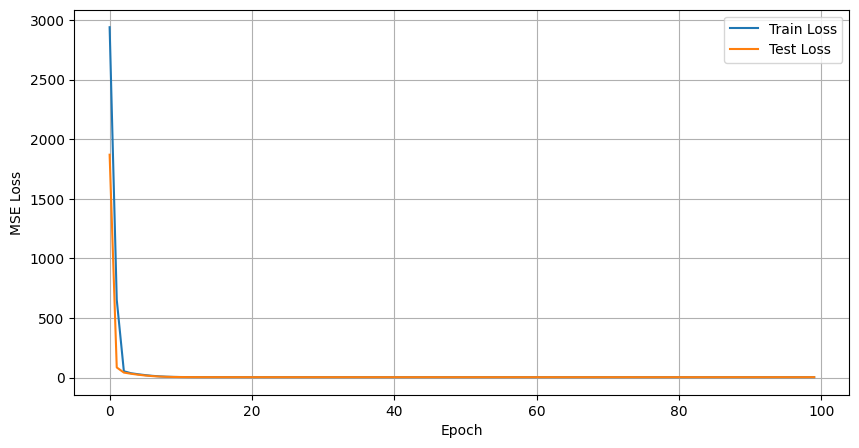

In [46]:
# Cell 9 — Loss plot
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.legend()
plt.show()

In [47]:
# Cell 10 — 성능 평가
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor.to(device)).cpu().numpy()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("==============================")
print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

Model Performance:
MSE: 4.848463875045126
RMSE: 2.2019227677294055
MAE: 1.7605006475448608
R²: 0.9869167333880589


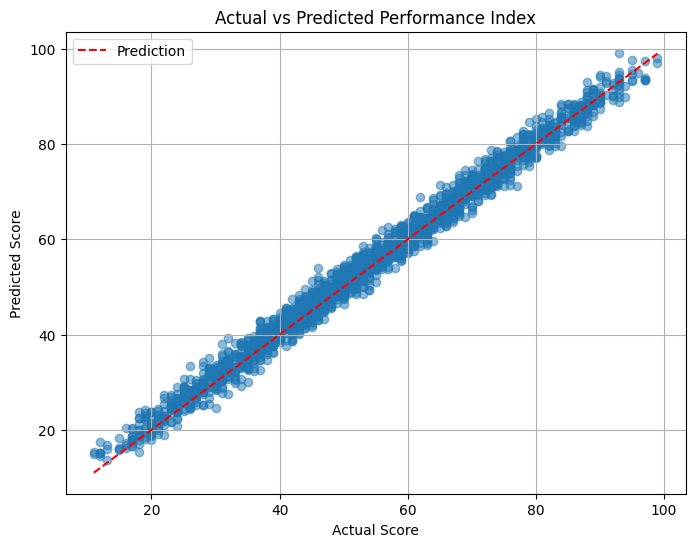

In [48]:
# Cell 11 — 실제 vs 예측
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", label="Prediction")

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Performance Index")
plt.legend()
plt.grid(True)
plt.show()

In [49]:
# Cell 12 — 모델 저장
torch.save(model.state_dict(), "student_performance_model.pth")
print("✓ Model saved: student_performance_model.pth")

✓ Model saved: student_performance_model.pth
